In [17]:
import pandas as pd

from sklearn.model_selection import train_test_split

from src.preprocessing import fit_preprocessing, transform_preprocessor
from src.models import compare_models, predict_and_score

from src.utils import roc_graph

## 코드 테스트

In [4]:
# 데이터 호출
df = pd.read_csv("../01_data/processed/model_df.csv")

In [5]:
# X/y split
X = df.drop('churned', axis=1)
y = df['churned']

# train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# tr/val split
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42, stratify=y_train)

In [6]:
# 데이터 전처리 함수 호출
X_tr_prep, encoders, scaler = fit_preprocessing(X_tr)
X_val_prep = transform_preprocessor(X_val, encoders, scaler)
X_test_prep = transform_preprocessor(X_test, encoders, scaler)

In [7]:
models = compare_models(X_tr, X_tr_prep, X_val, X_val_prep, y_tr, y_val)

In [8]:
train_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        train_scores[model.__class__.__name__] = predict_and_score(model, X_tr, y_tr)
        continue

    train_scores[model.__class__.__name__] = predict_and_score(model, X_tr_prep, y_tr)


CatBoostClassifier Results
Accuracy : 0.8656
F1 Score : 0.8670
ROC AUC  : 0.9495

XGBClassifier Results
Accuracy : 0.8821
F1 Score : 0.8838
ROC AUC  : 0.9577

LGBMClassifier Results
Accuracy : 0.8749
F1 Score : 0.8773
ROC AUC  : 0.9538

RandomForestClassifier Results
Accuracy : 0.8113
F1 Score : 0.8149
ROC AUC  : 0.9013


In [9]:
val_scores = {}

for model in models:
    name = model.__class__.__name__

    if name == 'CatBoostClassifier':
        val_scores[name] = predict_and_score(model, X_val, y_val)
        continue

    val_scores[name] = predict_and_score(model, X_val_prep, y_val)


CatBoostClassifier Results
Accuracy : 0.8377
F1 Score : 0.8393
ROC AUC  : 0.9363

XGBClassifier Results
Accuracy : 0.8394
F1 Score : 0.8424
ROC AUC  : 0.9363

LGBMClassifier Results
Accuracy : 0.8412
F1 Score : 0.8446
ROC AUC  : 0.9372

RandomForestClassifier Results
Accuracy : 0.8045
F1 Score : 0.8083
ROC AUC  : 0.8949


In [10]:
test_scores = {}

for model in models:

    if model.__class__.__name__ == 'CatBoostClassifier':
        test_scores[model.__class__.__name__] = predict_and_score(model, X_test, y_test)
        continue

    test_scores[model.__class__.__name__] = predict_and_score(model, X_test_prep, y_test)


CatBoostClassifier Results
Accuracy : 0.8460
F1 Score : 0.8478
ROC AUC  : 0.9415

XGBClassifier Results
Accuracy : 0.8493
F1 Score : 0.8519
ROC AUC  : 0.9416

LGBMClassifier Results
Accuracy : 0.8490
F1 Score : 0.8519
ROC AUC  : 0.9420

RandomForestClassifier Results
Accuracy : 0.8120
F1 Score : 0.8161
ROC AUC  : 0.9004


In [11]:
train_scores_df = pd.DataFrame(train_scores).T[['accuracy','f1','roc_auc']]
train_scores_df

,accuracy,f1,roc_auc
CatBoostClassifier,0.865578,0.866982,0.94953
XGBClassifier,0.882089,0.883809,0.957682
LGBMClassifier,0.874944,0.877261,0.953789
RandomForestClassifier,0.811289,0.814945,0.901312


In [12]:
val_scores_df = pd.DataFrame(val_scores).T[['accuracy', 'f1', 'roc_auc']]
val_scores_df

,accuracy,f1,roc_auc
CatBoostClassifier,0.8377,0.839291,0.936262
XGBClassifier,0.8394,0.842425,0.936306
LGBMClassifier,0.8412,0.844618,0.937171
RandomForestClassifier,0.8045,0.808277,0.894896


In [13]:
test_scores_df = pd.DataFrame(test_scores).T[['accuracy','f1','roc_auc']]
test_scores_df

,accuracy,f1,roc_auc
CatBoostClassifier,0.84596,0.847817,0.941541
XGBClassifier,0.84932,0.851862,0.941634
LGBMClassifier,0.849,0.85185,0.941974
RandomForestClassifier,0.81204,0.816079,0.900376


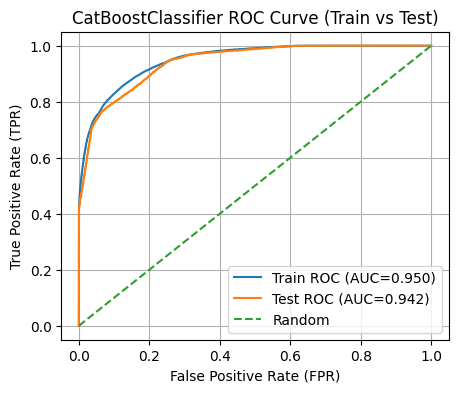

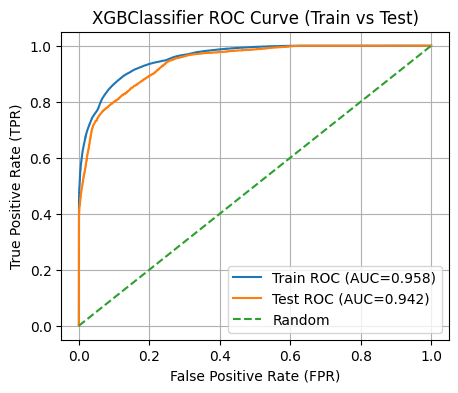

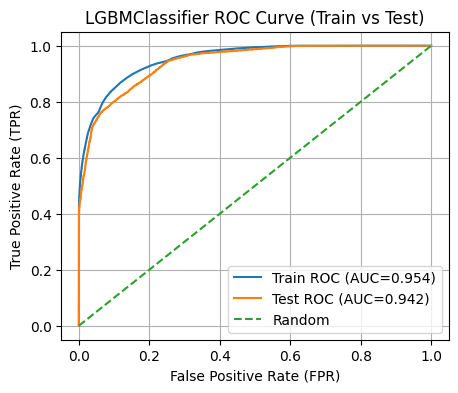

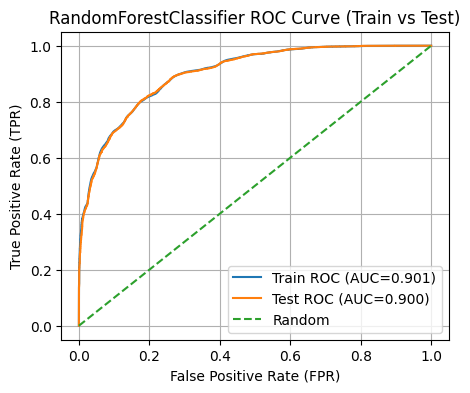

In [14]:
for model in models:

    name = model.__class__.__name__
    y_train_pred = train_scores[name]['y_proba']
    y_test_pred = test_scores[name]['y_proba']

    roc_graph(name, y_tr, y_train_pred, y_test, y_test_pred)

In [15]:
# F1 기준 정렬
val_scores_df = val_scores_df.sort_values(by='f1', ascending=False)
val_scores_df

,accuracy,f1,roc_auc
LGBMClassifier,0.8412,0.844618,0.937171
XGBClassifier,0.8394,0.842425,0.936306
CatBoostClassifier,0.8377,0.839291,0.936262
RandomForestClassifier,0.8045,0.808277,0.894896


In [16]:
# 최적 모델 확인
best_model_name = val_scores_df.index[0]
best_model_info = val_scores_df.iloc[0]

print("최적 모델명:", best_model_name)
print(best_model_info)

최적 모델명: LGBMClassifier
accuracy      0.8412
f1          0.844618
roc_auc     0.937171
Name: LGBMClassifier, dtype: object
